<a href="https://colab.research.google.com/github/AshakUmesh/Learn-Python/blob/main/Ciphers/IS_Ciphers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Simple Caesar shift cipher
def shift_cipher_encrypt(text, shift=3):
    result = ""
    for char in text:
        if char.isalpha():
            base = ord('A') if char.isupper() else ord('a')
            result += chr((ord(char) - base + shift) % 26 + base)
        else:
            result += char  # keep spaces unchanged
    return result

# Hamming distance (bit-level)
def hamming_distance_bits(s1, s2):
    xor_result = [ord(a) ^ ord(b) for a, b in zip(s1, s2)]
    return sum(bin(x).count('1') for x in xor_result)

# Diffusion score
def diffusion_score(s1, s2):
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

# Original plaintext
original_plaintext = "HELLO WORLD"
original_cipher = shift_cipher_encrypt(original_plaintext, shift=3)

# Results storage
results = []
bits_total = len(original_cipher) * 8

# For each character position (skip spaces)
for i, ch in enumerate(original_plaintext):
    if ch == " ":
        continue  # ✅ ignore spaces

    for replacement in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
        if ch.isalpha() and replacement == ch:
            continue  # skip identical replacement

        modified = original_plaintext[:i] + replacement + original_plaintext[i+1:]
        var_cipher = shift_cipher_encrypt(modified, shift=3)

        bit_diff = hamming_distance_bits(original_cipher, var_cipher)
        bit_same = bits_total - bit_diff
        score = diffusion_score(original_cipher, var_cipher)

        results.append({
            'Position Changed': i + 1,
            'Original Char': ch,
            'Replaced With': replacement,
            'Modified Plaintext': modified,
            'Bit Differences': bit_diff,
            'Bit Same': bit_same,
            'Diffusion Score': score
        })

# Convert to DataFrame
df = pd.DataFrame(results)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(df)

print("\nTotal rows generated:", df.shape[0])
print("\nCount per position:")
print(df.groupby("Position Changed").size())


     Position Changed Original Char Replaced With Modified Plaintext  Bit Differences  Bit Same  Diffusion Score
0                   1             H             A        AELLO WORLD                4        84         0.045455
1                   1             H             B        BELLO WORLD                3        85         0.034091
2                   1             H             C        CELLO WORLD                3        85         0.034091
3                   1             H             D        DELLO WORLD                2        86         0.022727
4                   1             H             E        EELLO WORLD                2        86         0.022727
5                   1             H             F        FELLO WORLD                1        87         0.011364
6                   1             H             G        GELLO WORLD                1        87         0.011364
7                   1             H             I        IELLO WORLD                3        85 

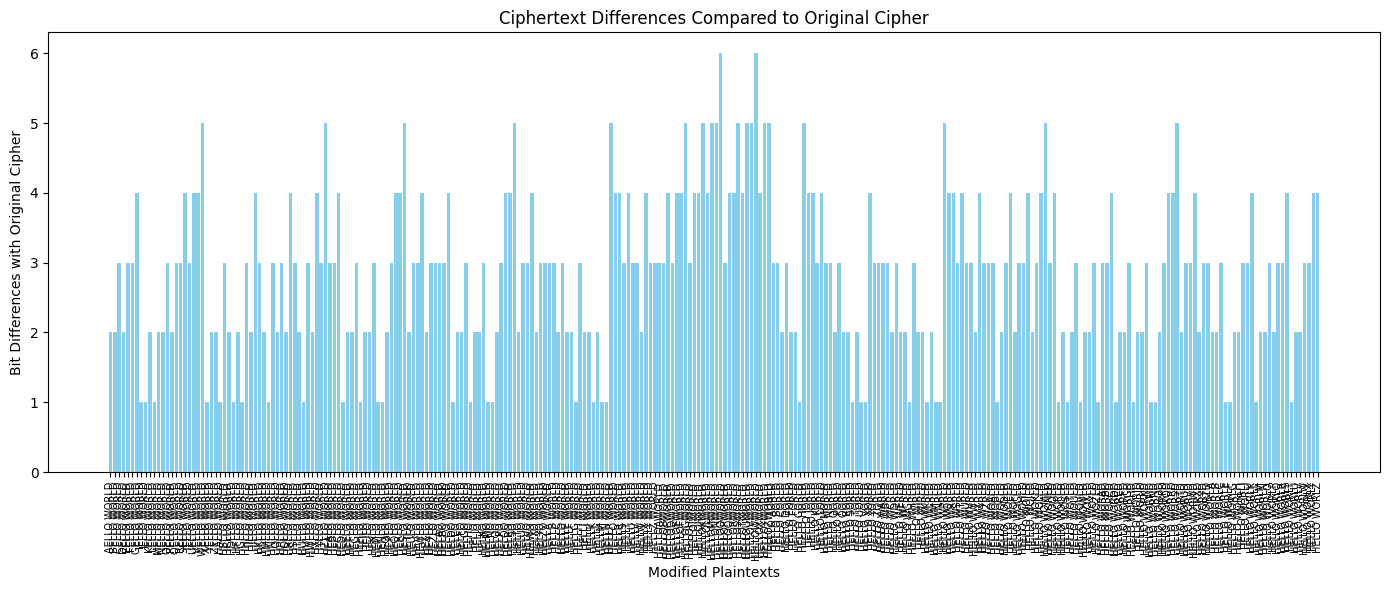

In [ ]:
plt.figure(figsize=(14, 6))
plt.bar(range(len(df)), df["Bit Differences"], color="skyblue")
plt.xticks(range(len(df)), df["Modified Plaintext"], rotation=90, fontsize=7)
plt.ylabel("Bit Differences with Original Cipher")
plt.xlabel("Modified Plaintexts")
plt.title("Ciphertext Differences Compared to Original Cipher")
plt.tight_layout()
plt.show()

    Original Key  Changed Key Ciphertext (Changed Key)  Bit Differences  Bit Same  Confusion Score
0              3            0              HELLO WORLD               27        61         0.306818
1              3            1              IFMMP XPSME               13        75         0.147727
2              3            2              JGNNQ YQTNF               16        72         0.181818
3              3            4              LIPPS ASVPH               31        57         0.352273
4              3            5              MJQQT BTWQI               25        63         0.284091
5              3            6              NKRRU CUXRJ               31        57         0.352273
6              3            7              OLSSV DVYSK               21        67         0.238636
7              3            8              PMTTW EWZTL               34        54         0.386364
8              3            9              QNUUX FXAUM               25        63         0.284091
9         

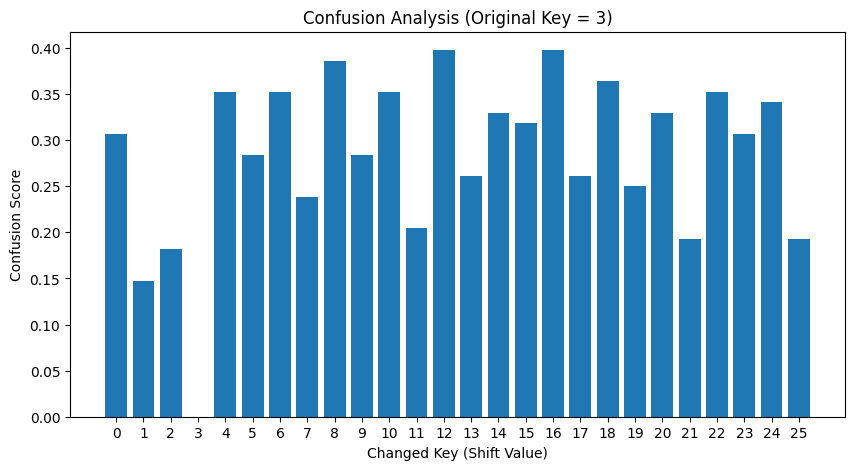


Total rows generated: 25


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Shift cipher
def shift_cipher_encrypt(text, shift=3):
    result = ""
    for char in text:
        if char.isalpha():
            base = ord('A') if char.isupper() else ord('a')
            result += chr((ord(char) - base + shift) % 26 + base)
        else:
            result += char
    return result

# Hamming distance (bit-level)
def hamming_distance_bits(s1, s2):
    xor_result = [ord(a) ^ ord(b) for a, b in zip(s1, s2)]
    return sum(bin(x).count('1') for x in xor_result)

# Confusion score
def confusion_score(s1, s2):
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

# Fixed plaintext
plaintext = "HELLO WORLD"

# Encrypt with original key
original_key = 3
original_cipher = shift_cipher_encrypt(plaintext, shift=original_key)

# Results storage
results = []
bits_total = len(original_cipher) * 8

# Try all possible keys (0–25)
for key in range(26):
    if key == original_key:
        continue  # skip identical key

    var_cipher = shift_cipher_encrypt(plaintext, shift=key)

    bit_diff = hamming_distance_bits(original_cipher, var_cipher)
    bit_same = bits_total - bit_diff
    score = confusion_score(original_cipher, var_cipher)

    results.append({
        'Original Key': original_key,
        'Changed Key': key,
        'Ciphertext (Changed Key)': var_cipher,
        'Bit Differences': bit_diff,
        'Bit Same': bit_same,
        'Confusion Score': score
    })

# Convert to DataFrame
df = pd.DataFrame(results)

# ✅ Print table
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df)

# ✅ Graph: Confusion Score vs. Changed Key
plt.figure(figsize=(10,5))
plt.bar(df["Changed Key"], df["Confusion Score"])
plt.xlabel("Changed Key (Shift Value)")
plt.ylabel("Confusion Score")
plt.title(f"Confusion Analysis (Original Key = {original_key})")
plt.xticks(range(26))
plt.show()

print("\nTotal rows generated:", df.shape[0])



=== Diffusion Analysis (ADFGVX) ===

   Position Changed Original Char Replaced With Modified Plaintext  \
0                 1             H             A           AELLO123   
1                 1             H             B           BELLO123   
2                 1             H             C           CELLO123   
3                 1             H             D           DELLO123   
4                 1             H             E           EELLO123   

   Bit Differences  Diffusion Score  
0                4         0.031250  
1                2         0.015625  
2                3         0.023438  
3                4         0.031250  
4                4         0.031250  

Total rows: 280


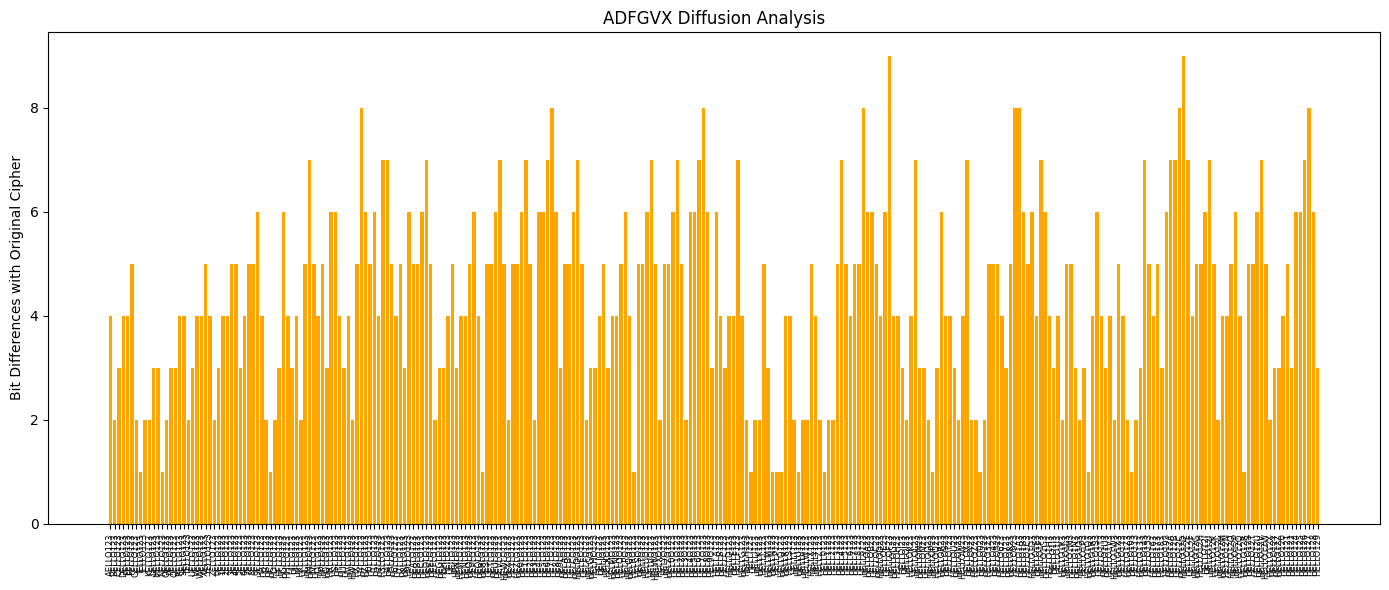


=== Confusion Analysis (ADFGVX) ===

  Original Key Changed Key Ciphertext (Changed Key)  Bit Differences  \
0          KEY        WORD         VXGXDXFVADVVDDFV               38   
1          KEY      CIPHER         DDVDVVFXDXVAFVXG               30   
2          KEY      SECRET         AFVDXVDVVFXDDVXG               32   
3          KEY       HELLO         DDGDXVXAXVVFVDFV               32   

   Confusion Score  
0         0.296875  
1         0.234375  
2         0.250000  
3         0.250000  


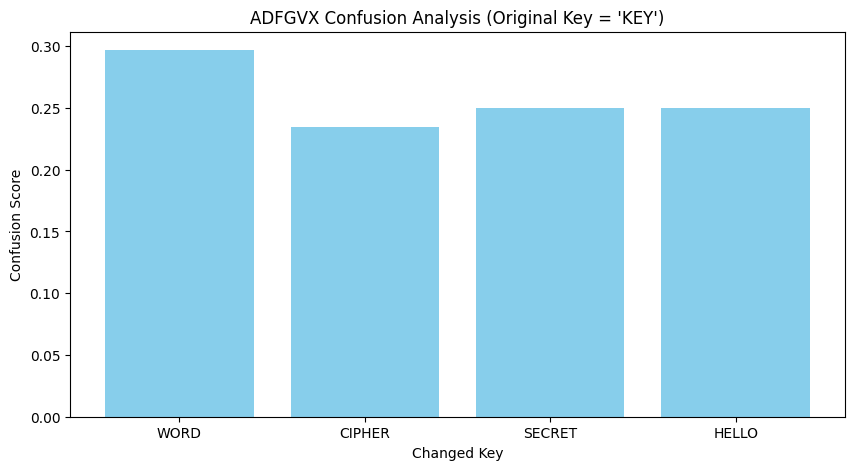

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# -----------------------------
# ADFGVX Cipher Implementation
# -----------------------------
symbols = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
adfgvx = "ADFGVX"

# Polybius square mapping
polybius_square = {}
i = 0
for r in adfgvx:
    for c in adfgvx:
        polybius_square[symbols[i]] = r + c
        i += 1

def adfgvx_encrypt(plaintext, key):
    plaintext = plaintext.upper().replace(" ", "")

    # Step 1: substitution using Polybius square
    substituted = "".join(polybius_square[ch] for ch in plaintext if ch in polybius_square)

    # Step 2: columnar transposition
    cols = len(key)
    rows = math.ceil(len(substituted) / cols)
    grid = [[""] * cols for _ in range(rows)]

    for i, ch in enumerate(substituted):
        grid[i // cols][i % cols] = ch

    # Sort key for transposition
    sorted_key = sorted([(ch, i) for i, ch in enumerate(key)])

    ciphertext = ""
    for _, idx in sorted_key:
        for row in grid:
            if row[idx] != "":
                ciphertext += row[idx]
    return ciphertext

# -----------------------------
# Helper Functions
# -----------------------------
def hamming_distance_bits(s1, s2):
    xor_result = [ord(a) ^ ord(b) for a, b in zip(s1, s2)]
    return sum(bin(x).count("1") for x in xor_result)

def diffusion_score(s1, s2):
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

def confusion_score(s1, s2):
    return hamming_distance_bits(s1, s2) / (len(s1) * 8)

# -----------------------------
# Diffusion Analysis
# -----------------------------
plaintext = "HELLO123"
key = "KEY"

original_cipher = adfgvx_encrypt(plaintext, key)
bits_total = len(original_cipher) * 8

diffusion_results = []

for i, ch in enumerate(plaintext):
    for replacement in symbols:
        if replacement == ch:
            continue
        modified = plaintext[:i] + replacement + plaintext[i+1:]
        var_cipher = adfgvx_encrypt(modified, key)
        bit_diff = hamming_distance_bits(original_cipher, var_cipher)
        score = diffusion_score(original_cipher, var_cipher)
        diffusion_results.append({
            "Position Changed": i + 1,
            "Original Char": ch,
            "Replaced With": replacement,
            "Modified Plaintext": modified,
            "Bit Differences": bit_diff,
            "Diffusion Score": score
        })

df_diffusion = pd.DataFrame(diffusion_results)

print("\n=== Diffusion Analysis (ADFGVX) ===\n")
print(df_diffusion.head())
print("\nTotal rows:", df_diffusion.shape[0])

plt.figure(figsize=(14,6))
plt.bar(range(len(df_diffusion)), df_diffusion["Bit Differences"], color="orange")
plt.xticks(range(len(df_diffusion)), df_diffusion["Modified Plaintext"], rotation=90, fontsize=6)
plt.ylabel("Bit Differences with Original Cipher")
plt.title("ADFGVX Diffusion Analysis")
plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Analysis
# -----------------------------
keys_to_test = ["KEY", "WORD", "CIPHER", "SECRET", "HELLO"]
original_cipher_conf = adfgvx_encrypt(plaintext, "KEY")
bits_total_conf = len(original_cipher_conf) * 8

confusion_results = []

for test_key in keys_to_test:
    if test_key == "KEY":
        continue
    var_cipher = adfgvx_encrypt(plaintext, test_key)
    bit_diff = hamming_distance_bits(original_cipher_conf, var_cipher)
    score = confusion_score(original_cipher_conf, var_cipher)
    confusion_results.append({
        "Original Key": "KEY",
        "Changed Key": test_key,
        "Ciphertext (Changed Key)": var_cipher,
        "Bit Differences": bit_diff,
        "Confusion Score": score
    })

df_confusion = pd.DataFrame(confusion_results)

print("\n=== Confusion Analysis (ADFGVX) ===\n")
print(df_confusion)

plt.figure(figsize=(10,5))
plt.bar(df_confusion["Changed Key"], df_confusion["Confusion Score"], color="skyblue")
plt.xlabel("Changed Key")
plt.ylabel("Confusion Score")
plt.title("ADFGVX Confusion Analysis (Original Key = 'KEY')")
plt.show()
